In [10]:
import os
import re

In [11]:
base_dir = ('/Users/zeinab/Documents/MSR_internship/manuscript/nature_communications'
            '/rebuttal/new_results/scvi/resampling_weights/scvi_every_20_epochs'
            '/resampling_weights/sctab/')
seeds = ['42', '43', '44', '45', '46']

# Example experiment for per-cell weight scatter plots (change as needed)
example_base_name = 'resampling_weights_sctab_AR_epoch300_seed42_scvi_ldim64_atlascount10000'
output_dir = '../figures/resampling_weight_correlation'
os.makedirs(output_dir, exist_ok=True)

In [12]:
# Collect all file paths and their stripped base names
all_files = []   # list of (base_name, full_path)

for seed in seeds:
    seed_dir = os.path.join(base_dir, seed)
    for root, dirs, files in os.walk(seed_dir):
        for fname in files:
            if not fname.endswith('.csv'):
                continue
            full_path = os.path.join(root, fname)
            # remove '_trackedepoch' and everything after it (including the extension)
            base_name = re.sub(r'_trackedepoch.*', '', fname)
            all_files.append((base_name, full_path))

print(f'Total files found: {len(all_files)}')

Total files found: 560


In [13]:
# Unique base names (order preserved)
unique_base_names = sorted(set(base_name for base_name, _ in all_files))

print(f'Unique base names: {len(unique_base_names)}')
for name in unique_base_names:
    print(' ', name)

Unique base names: 35
  resampling_weights_sctab_AR_epoch300_seed42_scvi_ldim64_atlascount0
  resampling_weights_sctab_AR_epoch300_seed42_scvi_ldim64_atlascount1
  resampling_weights_sctab_AR_epoch300_seed42_scvi_ldim64_atlascount10
  resampling_weights_sctab_AR_epoch300_seed42_scvi_ldim64_atlascount100
  resampling_weights_sctab_AR_epoch300_seed42_scvi_ldim64_atlascount1000
  resampling_weights_sctab_AR_epoch300_seed42_scvi_ldim64_atlascount10000
  resampling_weights_sctab_AR_epoch300_seed42_scvi_ldim64_atlascount50000
  resampling_weights_sctab_AR_epoch300_seed43_scvi_ldim64_atlascount0
  resampling_weights_sctab_AR_epoch300_seed43_scvi_ldim64_atlascount1
  resampling_weights_sctab_AR_epoch300_seed43_scvi_ldim64_atlascount10
  resampling_weights_sctab_AR_epoch300_seed43_scvi_ldim64_atlascount100
  resampling_weights_sctab_AR_epoch300_seed43_scvi_ldim64_atlascount1000
  resampling_weights_sctab_AR_epoch300_seed43_scvi_ldim64_atlascount10000
  resampling_weights_sctab_AR_epoch300_seed4

In [14]:
tracked_epochs = [0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280]

# For each base name, build a list of complete file paths (one per tracked epoch)
epoch_paths = {}   # base_name -> [full_path_epoch0, full_path_epoch20, ..., full_path_epoch280]
missing = []

for base_name in unique_base_names:
    seed = re.search(r'_seed(\d+)_', base_name).group(1)
    dir_path = os.path.join(base_dir, seed, 'scvi')

    paths = []
    for epoch in tracked_epochs:
        full_path = os.path.join(dir_path, f'{base_name}_trackedepoch{epoch}.csv')
        paths.append(full_path)
        if not os.path.isfile(full_path):
            missing.append(full_path)

    epoch_paths[base_name] = paths

total = len(unique_base_names) * len(tracked_epochs)
print(f'Expected files : {total}')
print(f'Found          : {total - len(missing)}')
print(f'Missing        : {len(missing)}')
if missing:
    print('\nMissing files:')
    for p in missing:
        print(' ', p)
else:
    print('\nAll expected files exist.')

# preview: show full paths for the first base name
key = unique_base_names[0]
print(f'\nExample — {key}:')
for p in epoch_paths[key]:
    print(' ', p)

Expected files : 525
Found          : 525
Missing        : 0

All expected files exist.

Example — resampling_weights_sctab_AR_epoch300_seed42_scvi_ldim64_atlascount0:
  /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal/new_results/scvi/resampling_weights/scvi_every_20_epochs/resampling_weights/sctab/42/scvi/resampling_weights_sctab_AR_epoch300_seed42_scvi_ldim64_atlascount0_trackedepoch0.csv
  /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal/new_results/scvi/resampling_weights/scvi_every_20_epochs/resampling_weights/sctab/42/scvi/resampling_weights_sctab_AR_epoch300_seed42_scvi_ldim64_atlascount0_trackedepoch20.csv
  /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal/new_results/scvi/resampling_weights/scvi_every_20_epochs/resampling_weights/sctab/42/scvi/resampling_weights_sctab_AR_epoch300_seed42_scvi_ldim64_atlascount0_trackedepoch40.csv
  /Users/zeinab/Documents/MSR_internship/manuscript/n

In [15]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr

def get_epoch(path):
    m = re.search(r'_trackedepoch(\d+)\.csv$', path)
    return int(m.group(1)) if m else -1

# Sort each base_name's paths by epoch number
epoch_paths_sorted = {
    base_name: sorted(paths, key=get_epoch)
    for base_name, paths in epoch_paths.items()
}

# Sanity-check: consecutive epochs must be exactly 20 apart
for base_name, paths in epoch_paths_sorted.items():
    for i in range(len(paths) - 1):
        ea, eb = get_epoch(paths[i]), get_epoch(paths[i + 1])
        assert eb - ea == 20, f"Non-consecutive epochs for {base_name}: {ea} → {eb}"
print("Epoch gap check passed: all consecutive gaps are exactly 20.")

# Compute Pearson and Spearman correlations between consecutive epoch pairs
records = []
n_rows_seen = set()

for base_name, paths in epoch_paths_sorted.items():
    for i in range(len(paths) - 1):
        path_a = paths[i]
        path_b = paths[i + 1]
        epoch_a = get_epoch(path_a)
        epoch_b = get_epoch(path_b)

        w_a = pd.read_csv(path_a)['resampling_weight'].values
        w_b = pd.read_csv(path_b)['resampling_weight'].values

        assert len(w_a) == len(w_b), (
            f"Row count mismatch for {base_name} epochs {epoch_a}→{epoch_b}: "
            f"{len(w_a)} vs {len(w_b)}"
        )
        n_rows_seen.add(len(w_a))

        pearson_r, _  = pearsonr(w_a, w_b)
        spearman_r, _ = spearmanr(w_a, w_b)

        records.append({
            'base_name':  base_name,
            'epoch_from': epoch_a,
            'epoch_to':   epoch_b,
            'epoch_pair': f'{epoch_a}→{epoch_b}',
            'pearson':    pearson_r,
            'spearman':   spearman_r,
        })

assert len(n_rows_seen) == 1, f"Inconsistent row counts across pairs: {n_rows_seen}"
print(f"Row count check passed: all pairs have {n_rows_seen.pop()} weights.")

corr_df = pd.DataFrame(records)
print(f"Total records : {len(corr_df)}  "
      f"({len(epoch_paths_sorted)} base names × {len(tracked_epochs)-1} consecutive pairs)")
print(corr_df.head())


Epoch gap check passed: all consecutive gaps are exactly 20.
Row count check passed: all pairs have 90000 weights.
Total records : 490  (35 base names × 14 consecutive pairs)
                                           base_name  epoch_from  epoch_to  \
0  resampling_weights_sctab_AR_epoch300_seed42_sc...           0        20   
1  resampling_weights_sctab_AR_epoch300_seed42_sc...          20        40   
2  resampling_weights_sctab_AR_epoch300_seed42_sc...          40        60   
3  resampling_weights_sctab_AR_epoch300_seed42_sc...          60        80   
4  resampling_weights_sctab_AR_epoch300_seed42_sc...          80       100   

  epoch_pair   pearson  spearman  
0       0→20  0.378933  0.475200  
1      20→40  0.666969  0.698230  
2      40→60  0.797090  0.745879  
3      60→80  0.843425  0.800289  
4     80→100  0.868586  0.844579  


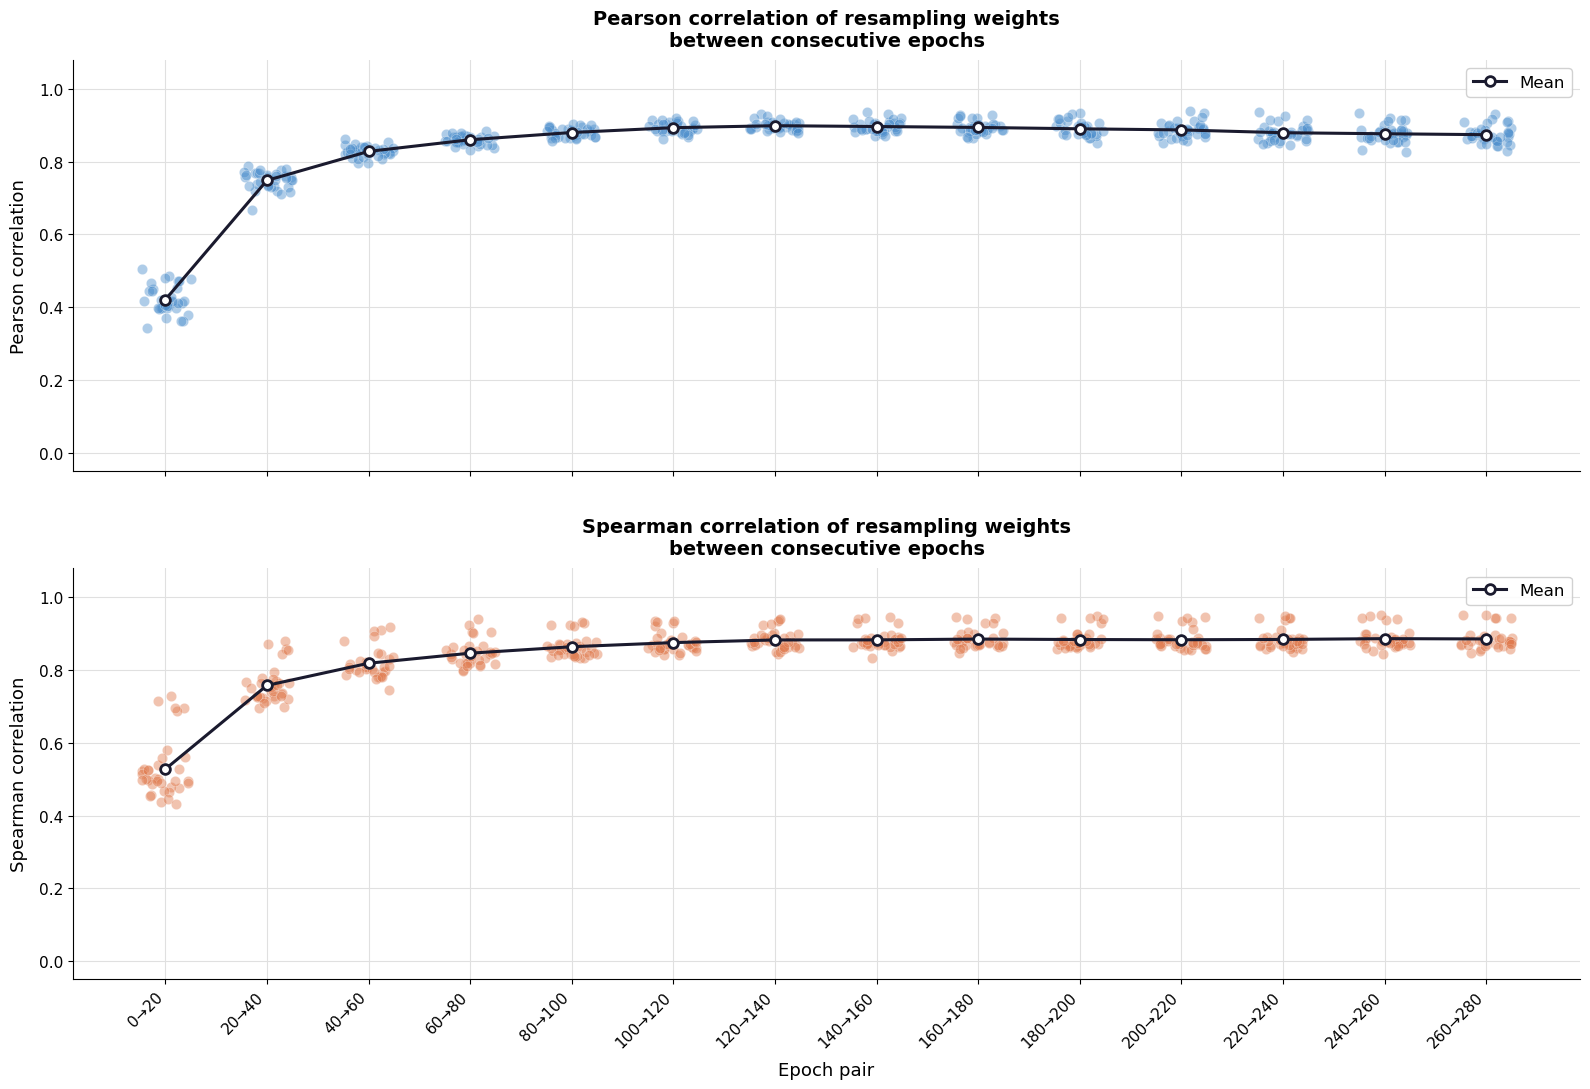

Saved: ../figures/resampling_weight_correlation/resampling_weight_correlations_consecutive_epochs.png


In [16]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'grid.linewidth': 0.8,
    'axes.axisbelow': True,
})

epoch_pairs = sorted(corr_df['epoch_pair'].unique(), key=lambda s: int(s.split('\u2192')[0]))
x_map = {ep: i for i, ep in enumerate(epoch_pairs)}
x_pos = list(range(len(epoch_pairs)))

fig, axes = plt.subplots(2, 1, figsize=(16, 11), sharex=True)

plot_cfg = [
    ('pearson',  '#4C8ECC', 'Pearson correlation',  'Pearson correlation of resampling weights\nbetween consecutive epochs'),
    ('spearman', '#E07B4F', 'Spearman correlation', 'Spearman correlation of resampling weights\nbetween consecutive epochs'),
]

for ax, (metric, color, ylabel, title) in zip(axes, plot_cfg):
    for base_name in corr_df['base_name'].unique():
        sub = corr_df[corr_df['base_name'] == base_name].sort_values('epoch_from')
        xs = [x_map[ep] + np.random.uniform(-0.25, 0.25) for ep in sub['epoch_pair']]
        ax.scatter(xs, sub[metric].values, alpha=0.45, s=55,
                   color=color, edgecolors='white', linewidths=0.4, zorder=3)

    means = (corr_df.groupby('epoch_from')[metric].mean()
             .reset_index().sort_values('epoch_from'))
    means['epoch_pair'] = means['epoch_from'].astype(str) + '\u2192' + (means['epoch_from'] + 20).astype(str)
    mean_xs = [x_map[ep] for ep in means['epoch_pair']]
    ax.plot(mean_xs, means[metric].values, '-o', color='#1a1a2e',
            linewidth=2.2, markersize=7, markerfacecolor='white',
            markeredgecolor='#1a1a2e', markeredgewidth=2, label='Mean', zorder=5)

    ax.set_yticks(np.arange(0, 1.1, 0.2))
    ax.set_ylabel(ylabel, fontsize=13, labelpad=8)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
    ax.set_ylim(-0.05, 1.08)
    ax.tick_params(axis='both', labelsize=11)
    ax.legend(fontsize=12, framealpha=0.9, edgecolor='#cccccc')

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(epoch_pairs, rotation=45, ha='right', fontsize=11)
axes[1].set_xlabel('Epoch pair', fontsize=13, labelpad=8)

plt.tight_layout(h_pad=3)
out_path = os.path.join(output_dir, 'resampling_weight_correlations_consecutive_epochs.png')
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {out_path}')


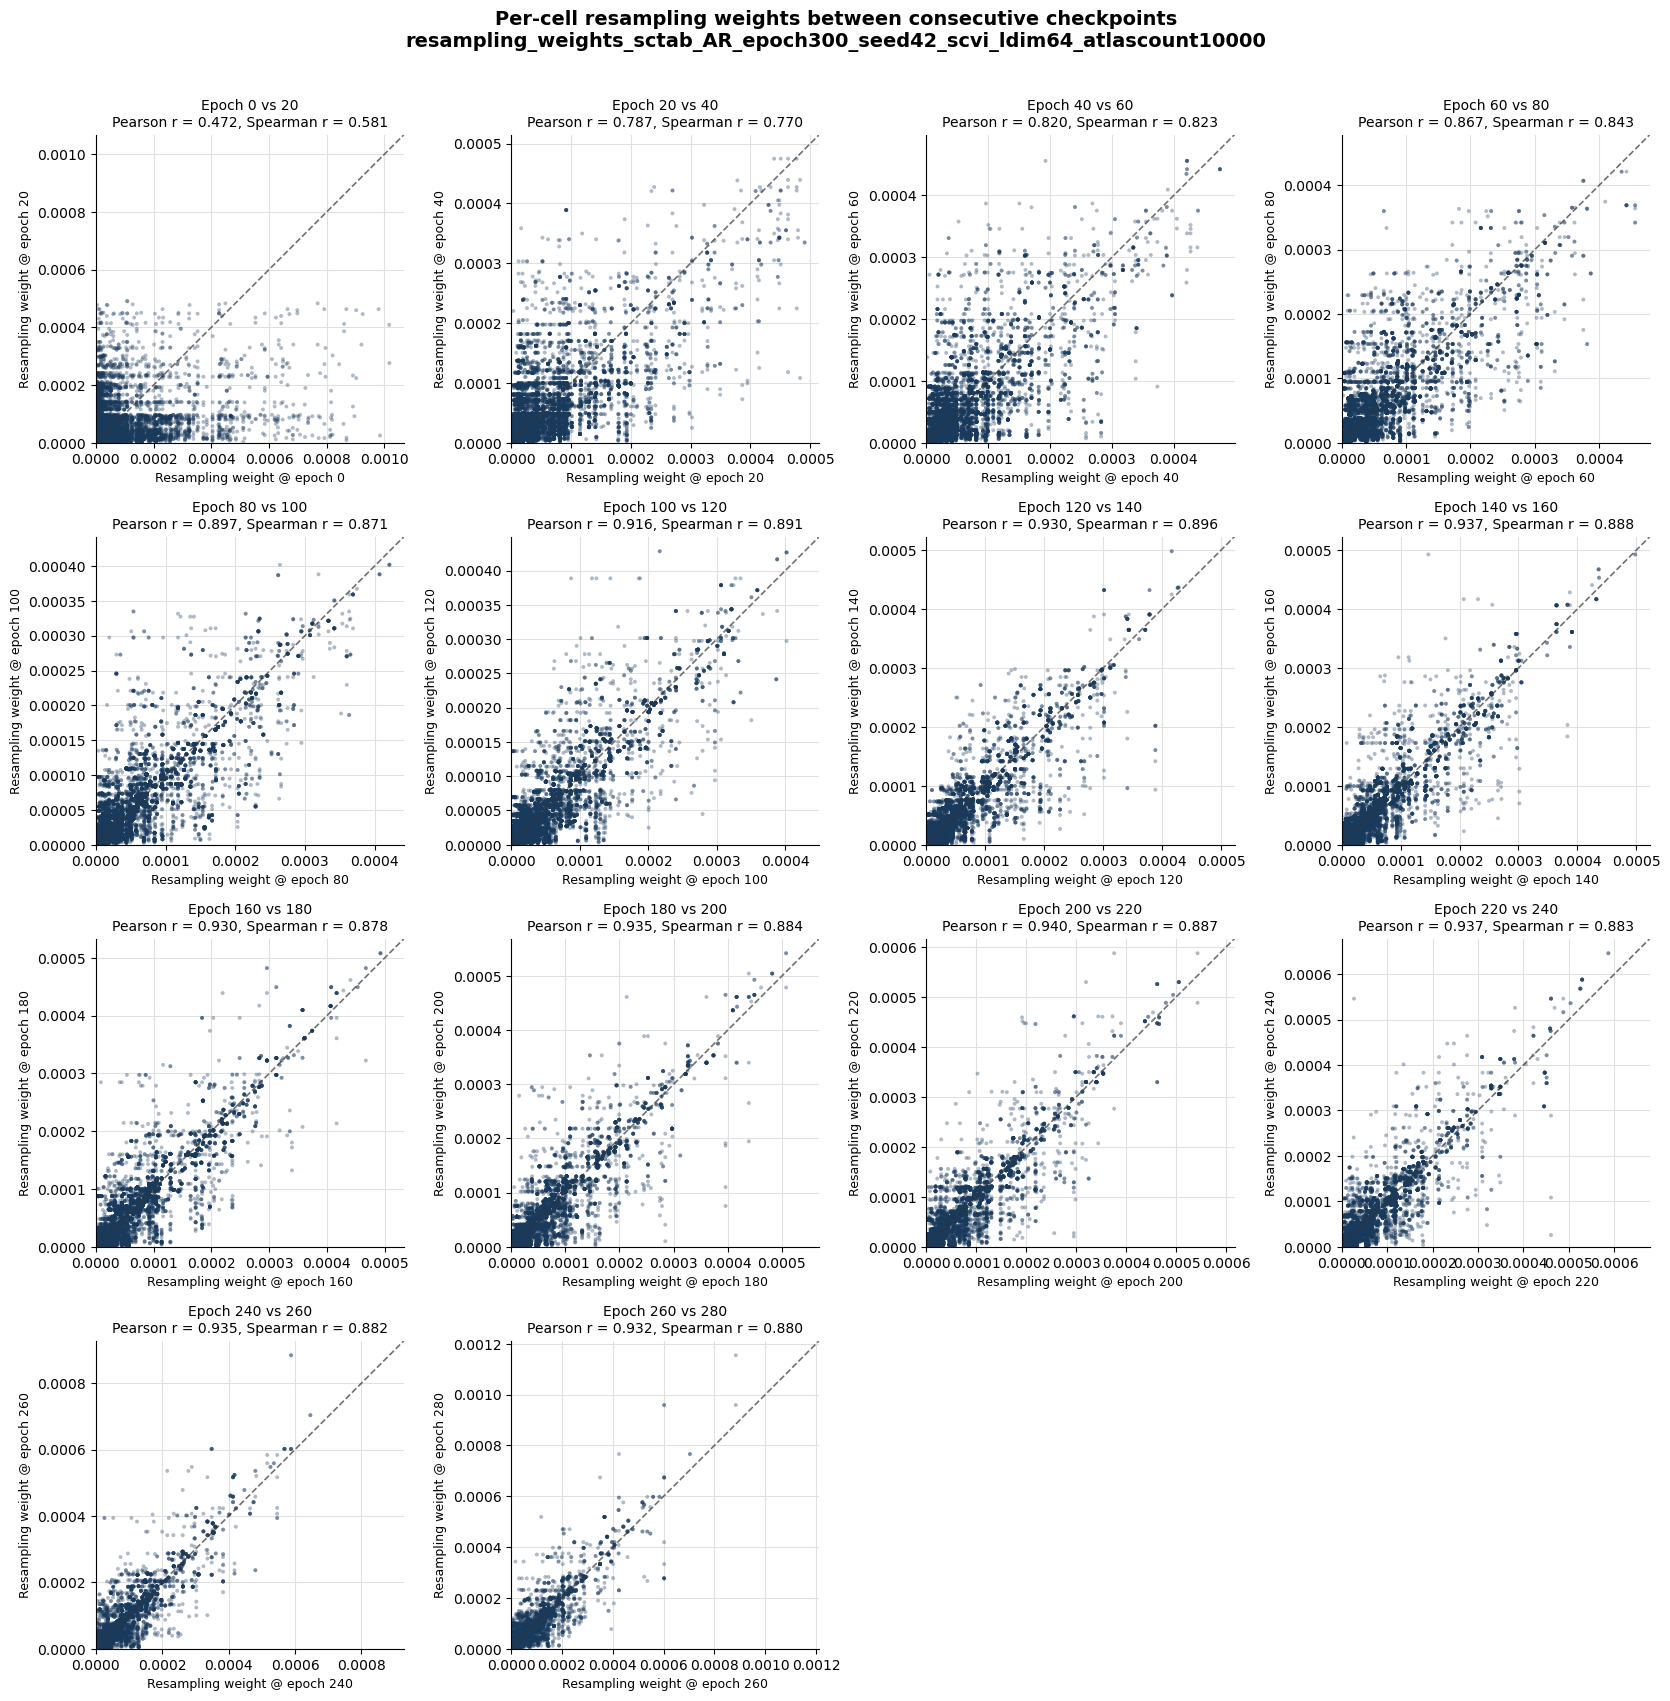

Saved: ../figures/resampling_weight_correlation/resampling_weight_scatter_consecutive_resampling_weights_sctab_AR_epoch300_seed42_scvi_ldim64_atlascount10000.png


In [17]:
# --- Scatter plots: per-cell resampling weights between consecutive epochs ---
# Each point is one cell; x = weight at epoch t, y = weight at epoch t+20

if example_base_name not in epoch_paths_sorted:
    raise ValueError(
        f'example_base_name not found: {example_base_name}\n'
        f'Available examples include: {unique_base_names[:3]} ...'
    )

example_paths = epoch_paths_sorted[example_base_name]
n_pairs = len(example_paths) - 1
ncols = 4
nrows = int(np.ceil(n_pairs / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4.2 * nrows))
axes = np.atleast_1d(axes).flatten()

for i in range(n_pairs):
    path_a, path_b = example_paths[i], example_paths[i + 1]
    epoch_a, epoch_b = get_epoch(path_a), get_epoch(path_b)

    w_a = pd.read_csv(path_a)['resampling_weight'].values
    w_b = pd.read_csv(path_b)['resampling_weight'].values

    ax = axes[i]
    ax.scatter(
        w_a, w_b,
        s=8, alpha=0.35, color='#1a3a5c',
        edgecolors='none', rasterized=True,
    )

    lim = max(w_a.max(), w_b.max()) * 1.05
    ax.plot([0, lim], [0, lim], color='#333333', linestyle='--', linewidth=1.2, alpha=0.7)

    pearson_r, _ = pearsonr(w_a, w_b)
    spearman_r, _ = spearmanr(w_a, w_b)

    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(
        f'Epoch {epoch_a} vs {epoch_b}\n'
        f'Pearson r = {pearson_r:.3f}, Spearman r = {spearman_r:.3f}',
        fontsize=10,
    )
    ax.set_xlabel(f'Resampling weight @ epoch {epoch_a}', fontsize=9)
    ax.set_ylabel(f'Resampling weight @ epoch {epoch_b}', fontsize=9)

for j in range(n_pairs, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    'Per-cell resampling weights between consecutive checkpoints\n'
    f'{example_base_name}',
    fontsize=14, fontweight='bold', y=1.01,
)
plt.tight_layout()
out_path = os.path.join(
    output_dir,
    f'resampling_weight_scatter_consecutive_{example_base_name}.png',
)
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {out_path}')

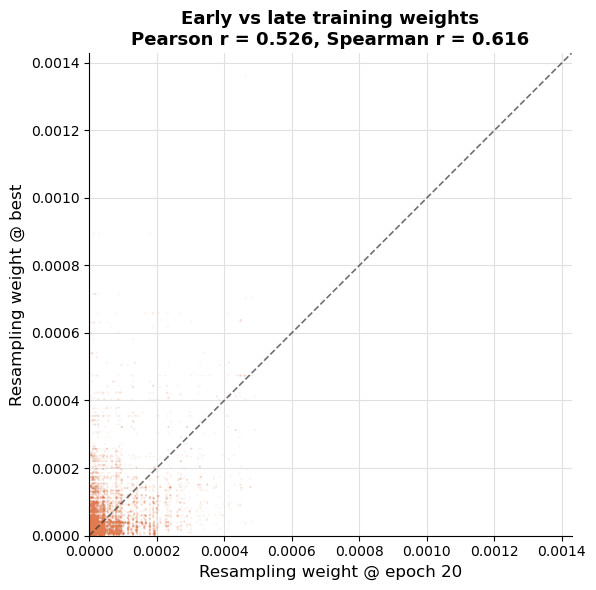

Saved: ../figures/resampling_weight_correlation/resampling_weight_scatter_epoch20_vs_best_resampling_weights_sctab_AR_epoch300_seed42_scvi_ldim64_atlascount10000.png


In [18]:
# --- Optional: early vs late training scatter (epoch 20 vs best) ---
early_epoch = 20
late_epoch = 'best'

early_path = os.path.join(
    base_dir,
    re.search(r'_seed(\d+)_', example_base_name).group(1),
    'scvi',
    f'{example_base_name}_trackedepoch{early_epoch}.csv',
)
late_path = os.path.join(
    base_dir,
    re.search(r'_seed(\d+)_', example_base_name).group(1),
    'scvi',
    f'{example_base_name}_trackedepoch{late_epoch}.csv',
)

if os.path.isfile(early_path) and os.path.isfile(late_path):
    w_early = pd.read_csv(early_path)['resampling_weight'].values
    w_late = pd.read_csv(late_path)['resampling_weight'].values

    fig, ax = plt.subplots(figsize=(6.5, 6))
    ax.scatter(
        w_early, w_late,
        s=2, alpha=0.1, color='#E07B4F',
        edgecolors='none', rasterized=True,
    )

    lim = max(w_early.max(), w_late.max()) * 1.05
    ax.plot([0, lim], [0, lim], color='#333333', linestyle='--', linewidth=1.2, alpha=0.7)

    pearson_r, _ = pearsonr(w_early, w_late)
    spearman_r, _ = spearmanr(w_early, w_late)

    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel(f'Resampling weight @ epoch {early_epoch}', fontsize=12)
    ax.set_ylabel(f'Resampling weight @ {late_epoch}', fontsize=12)
    ax.set_title(
        f'Early vs late training weights\n'
        f'Pearson r = {pearson_r:.3f}, Spearman r = {spearman_r:.3f}',
        fontsize=13, fontweight='bold',
    )

    plt.tight_layout()
    out_path = os.path.join(
        output_dir,
        f'resampling_weight_scatter_epoch{early_epoch}_vs_{late_epoch}_{example_base_name}.png',
    )
    plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved: {out_path}')
else:
    print(f'Skipping early vs late plot; missing file(s):\n  {early_path}\n  {late_path}')

In [21]:
# --- Expected unique-cell coverage per checkpoint ---
# For each checkpoint: normalize weights to probabilities p, then draw N samples
# with replacement (N = number of training cells, as in AR mini-batch resampling).
# Expected fraction of unique cells = 1 - mean_i (1 - p_i)^N

def expected_unique_coverage(p, m):
    """E[fraction of distinct cells] for m weighted draws with replacement."""
    miss = np.exp(m * np.log1p(-p))
    return 1.0 - miss.mean()


def parse_experiment_meta(base_name):
    return {
        'seed': int(re.search(r'_seed(\d+)_', base_name).group(1)),
        'atlas_count': int(re.search(r'_atlascount(\d+)', base_name).group(1)),
    }


coverage_records = []
for base_name, paths in epoch_paths_sorted.items():
    meta = parse_experiment_meta(base_name)
    for path in paths:
        epoch = get_epoch(path)
        w = pd.read_csv(path)['resampling_weight'].values
        w = w[np.isfinite(w) & (w >= 0)]
        n_cells = w.size
        p = w #/ w.sum()
        coverage = expected_unique_coverage(p, n_cells)

        coverage_records.append({
            'base_name': base_name,
            'seed': meta['seed'],
            'atlas_count': meta['atlas_count'],
            'epoch': epoch,
            'n_cells': n_cells,
            'coverage': coverage,
            'n_covered': coverage * n_cells,
        })

coverage_df = pd.DataFrame(coverage_records).sort_values(['atlas_count', 'seed', 'epoch'])
coverage_path = os.path.join(output_dir, 'resampling_weight_coverage.csv')
coverage_df.to_csv(coverage_path, index=False)

coverage_summary = (
    coverage_df.groupby(['atlas_count', 'epoch'], as_index=False)
    .agg(
        coverage_mean=('coverage', 'mean'),
        coverage_std=('coverage', 'std'),
        n_covered_mean=('n_covered', 'mean'),
        n_seeds=('seed', 'nunique'),
    )
    .sort_values(['atlas_count', 'epoch'])
)
summary_path = os.path.join(output_dir, 'resampling_weight_coverage_summary.csv')
coverage_summary.to_csv(summary_path, index=False)

n_cells_ref = int(coverage_df.n_cells.iloc[0])
uniform_ceiling = 1.0 - (1.0 - 1.0 / n_cells_ref) ** n_cells_ref

print(f'Coverage rows loaded: {len(coverage_df)}')
print(f'Uniform baseline (m=N={n_cells_ref:,}): {uniform_ceiling:.4f}')
print(f'Saved: {coverage_path}')
print(f'Saved: {summary_path}')
print(coverage_df.head())

Coverage rows loaded: 525
Uniform baseline (m=N=90,000): 0.6321
Saved: ../figures/resampling_weight_correlation/resampling_weight_coverage.csv
Saved: ../figures/resampling_weight_correlation/resampling_weight_coverage_summary.csv
                                           base_name  seed  atlas_count  \
0  resampling_weights_sctab_AR_epoch300_seed42_sc...    42            0   
1  resampling_weights_sctab_AR_epoch300_seed42_sc...    42            0   
2  resampling_weights_sctab_AR_epoch300_seed42_sc...    42            0   
3  resampling_weights_sctab_AR_epoch300_seed42_sc...    42            0   
4  resampling_weights_sctab_AR_epoch300_seed42_sc...    42            0   

   epoch  n_cells  coverage     n_covered  
0      0    90000  0.309374  27843.663225  
1     20    90000  0.383509  34515.814403  
2     40    90000  0.401657  36149.172492  
3     60    90000  0.386267  34764.042744  
4     80    90000  0.380643  34257.827595  


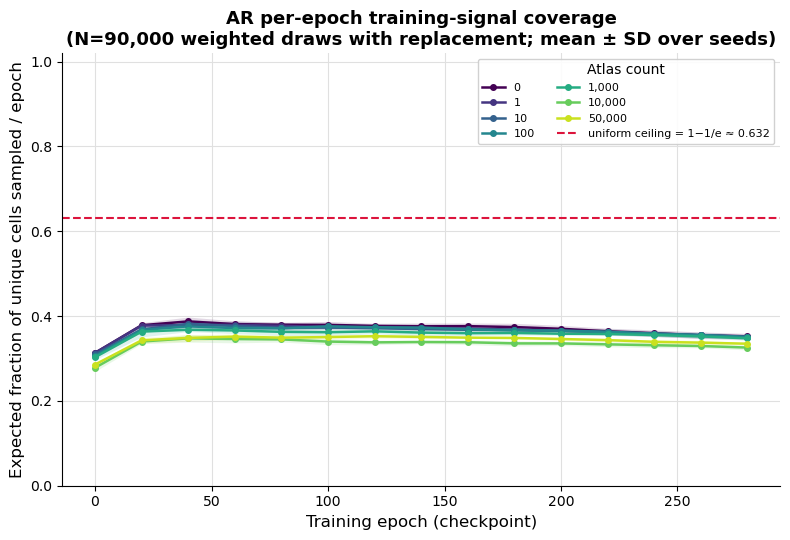

Saved: ../figures/resampling_weight_correlation/resampling_weight_coverage.png


In [22]:
# --- Plot: expected fraction of unique cells sampled per epoch ---
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'grid.linewidth': 0.8,
    'axes.axisbelow': True,
})

atlas_values = sorted(coverage_df['atlas_count'].unique())
cmap = plt.cm.viridis(np.linspace(0, 0.92, len(atlas_values)))

fig, ax = plt.subplots(figsize=(8, 5.5))
for color, atlas_count in zip(cmap, atlas_values):
    sub = coverage_df[coverage_df['atlas_count'] == atlas_count]
    agg = (
        sub.groupby('epoch')['coverage']
        .agg(mean='mean', std='std')
        .reset_index()
        .sort_values('epoch')
    )
    ax.plot(
        agg['epoch'], agg['mean'],
        '-o', ms=4, color=color, lw=1.8, label=f'{atlas_count:,}',
    )
    ax.fill_between(
        agg['epoch'],
        agg['mean'] - agg['std'],
        agg['mean'] + agg['std'],
        color=color, alpha=0.15, linewidth=0,
    )

ax.axhline(
    uniform_ceiling, ls='--', color='crimson', lw=1.5,
    label=f'uniform ceiling = 1\u22121/e \u2248 {uniform_ceiling:.3f}',
)
ax.set_xlabel('Training epoch (checkpoint)', fontsize=12)
ax.set_ylabel('Expected fraction of unique cells sampled / epoch', fontsize=12)
ax.set_title(
    f'AR per-epoch training-signal coverage\n'
    f'(N={n_cells_ref:,} weighted draws with replacement; mean \u00b1 SD over seeds)',
    fontsize=13, fontweight='bold',
)
ax.legend(title='Atlas count', fontsize=8, ncol=2, framealpha=0.9)
ax.set_ylim(0, 1.02)
fig.tight_layout()

out_path = os.path.join(output_dir, 'resampling_weight_coverage.png')
fig.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {out_path}')